# Classificació binària

## Llibreries

In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall

## Càrrega de dades

El dataset Titanic és un dataset clàssic de classificació binària (disponible directament des de seaborn).

Cada fila és un passatger. A diferència de les dades de breast cancer, **combina features numèriques** (`age`, `fare`, ...) **amb features categòriques** (`sex`, `embarked`, `pclass`) i conté **missing values** — així que necessita un preprocessament real abans de poder alimentar una xarxa neuronal.

El target `survived` indica si el passatger va sobreviure (`1`) o no (`0`).

In [20]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [21]:
df.shape

(891, 15)

Balanç de classes (lleugerament desequilibrat):

In [22]:
df['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

Missing values (`age`, `embarked` i sobretot `deck` tenen buits — els tractem al pipeline):

In [23]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## Split de dades

Primer triem un conjunt de features, descartant columnes que són:

- **leaky** — `alive` és el mateix target (`'yes'`/`'no'`), així que donaria puntuacions perfectes però sense sentit;
- **redundants** — `class`, `who`, `adult_male`, `embark_town` i `alone` només dupliquen informació que ja hi ha a `pclass`, `sex`, `age` i `sibsp`/`parch`;
- **majoritàriament buides** — `deck`.

Fem el split estratificat (stratify) perquè les classes estan lleugerament desequilibrades.

In [24]:
# Grups de features (es fan servir tant per al split com per al pipeline de preprocessament)
features_num = ['age', 'fare', 'sibsp', 'parch']
features_cat = ['pclass', 'sex', 'embarked']

X = df[features_num + features_cat]
y = df['survived']

# Split Train / Test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Split Train / Validation
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.2, random_state=42)

## Feature engineering

Una xarxa neuronal necessita entrades **numèriques, escalades i completes**. Construïm un `ColumnTransformer` que tracta cada tipus de columna de manera diferent:

- **numèriques** (`age`, `fare`, `sibsp`, `parch`) → imputa els missing values amb la mediana i després estandarditza (mitjana 0, std 1)
- **categòriques** (`pclass`, `sex`, `embarked`) → imputa els missing values amb la categoria més freqüent i després aplica **one-hot encoding**

Embolcallar-ho tot dins d'un `Pipeline` ens permet **fer el fit només amb les dades de train** i reutilitzar exactament la mateixa transformació sobre validation i test — cosa que evita el data leakage. Com que ara l'escalat es fa aquí, ja no necessitem cap capa `Normalization` de Keras al model.

In [25]:
# Un sub-pipeline per cada tipus de columna
numeric = Pipeline([
    ('impute', SimpleImputer(strategy='median')),      # omple els missing d'age/fare
    ('scale', StandardScaler()),                       # mitjana 0, std 1
])

categorical = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),                   # omple els missing d'embarked
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),  # one-hot encoding (sortida densa)
])

# Envia cada grup de columnes al seu sub-pipeline
preprocessor = ColumnTransformer([
    ('num', numeric, features_num),
    ('cat', categorical, features_cat),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [26]:
# Fem el fit NOMÉS amb les dades de train i després apliquem la mateixa transformació a cada split (sense leakage)
X_train_p = preprocessor.fit_transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

X_train_p.shape

(569, 12)

In [27]:
# Noms de les features després de la transformació (primer les numèriques, després les categories expandides amb one-hot)
preprocessor.get_feature_names_out()

array(['num__age', 'num__fare', 'num__sibsp', 'num__parch',
       'cat__pclass_1', 'cat__pclass_2', 'cat__pclass_3',
       'cat__sex_female', 'cat__sex_male', 'cat__embarked_C',
       'cat__embarked_Q', 'cat__embarked_S'], dtype=object)

## Modelatge

In [28]:
# Definim el model de NN (l'entrada ja ve escalada + one-hot encoded pel pipeline)

model = Sequential([
    Input((X_train_p.shape[1],)),
    Dense(10, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=[Precision(), Recall()]
)

In [29]:
results = model.fit(X_train_p, y_train, validation_data=(X_val_p, y_val), epochs=30, batch_size=32)

Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6490 - precision_1: 0.5235 - recall_1: 0.3578 - val_loss: 0.5682 - val_precision_1: 0.6923 - val_recall_1: 0.1636
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5073 - precision_1: 0.8532 - recall_1: 0.4266 - val_loss: 0.4991 - val_precision_1: 0.7255 - val_recall_1: 0.6727
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4446 - precision_1: 0.7931 - recall_1: 0.7385 - val_loss: 0.4728 - val_precision_1: 0.7547 - val_recall_1: 0.7273
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4161 - precision_1: 0.7826 - recall_1: 0.7431 - val_loss: 0.4629 - val_precision_1: 0.7755 - val_recall_1: 0.6909
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3992 - precision_1: 0.8020 - recall_1: 0.7248 - val_loss: 0.4577 - val_precision_1: 0.7872 - val_recall_1: 0.6727
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3863 - precision_1: 0.8368 - recall_1: 0.7294 - val_loss: 0.4480 - va

Compte amb l'overfitting!

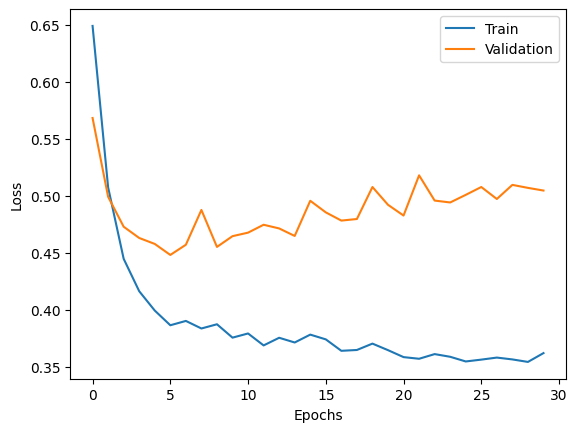

In [30]:
# Visualitza el loss d'entrenament al llarg de les epochs

plt.plot(results.history['loss'], label='Train')
plt.plot(results.history['val_loss'], label='Validation')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

Precision i recall:

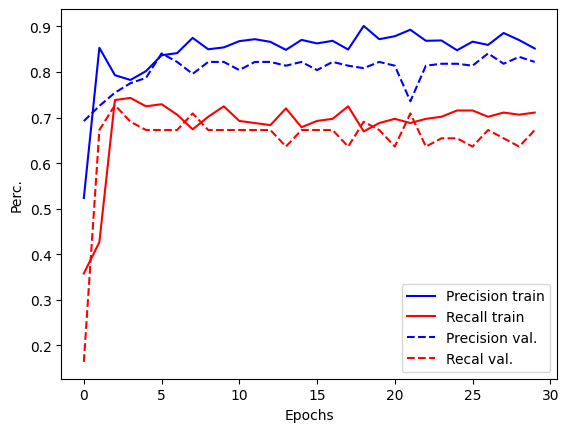

In [31]:
# Visualitza precision i recall al llarg de les epochs

# Obtenim les claus de precision i recall de l'history (canvien de nom després de cada execució)
prec_key = [k for k in results.history.keys() if 'precision' in k][0]
rec_key = [k for k in results.history.keys() if 'recall' in k][0]

plt.plot(results.history[prec_key], color='blue', label='Precision train')
plt.plot(results.history[rec_key], color='red', label='Recall train')
plt.plot(results.history[f'val_{prec_key}'], color='blue', linestyle='--', label='Precision val.')
plt.plot(results.history[f'val_{rec_key}'], color='red', linestyle='--', label='Recal val.')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Perc.')
plt.show()

In [32]:
# Avalua amb les mètriques indicades (quan vam compilar el model) i la funció de loss

train_loss, train_prec, train_rec = model.evaluate(X_train_p, y_train, verbose=0)
val_loss, val_prec, val_rec = model.evaluate(X_val_p, y_val, verbose=0)

print(f'Train Precision: {train_prec:.2f}')
print(f'Train Recall: {train_rec:.2f}')
print()
print(f'Validation Precision: {val_prec:.2f}')
print(f'Validation Recall: {val_rec:.2f}')

Train Precision: 0.88
Train Recall: 0.70

Validation Precision: 0.82
Validation Recall: 0.67


## Avaluació sobre test

In [33]:
# Avaluem test després de l'entrenament

test_loss, test_prec, test_rec = model.evaluate(X_test_p, y_test, verbose=0)
print(f'Test Precision: {test_prec:.2f}')
print(f'Test Recall: {test_rec:.2f}')

Test Precision: 0.80
Test Recall: 0.65


In [34]:
# Retorna les probabilitats de la classe 1 donades per la funció sigmoide

y_test_preds = model.predict(X_test_p, verbose=0)
y_test_preds

array([[0.13397527],
       [0.02956176],
       [0.18773799],
       [0.0798802 ],
       [0.72229487],
       [0.28338528],
       [0.90545917],
       [0.43039963],
       [0.4143099 ],
       [0.08289126],
       [0.10730476],
       [0.12836199],
       [0.41539606],
       [0.1774262 ],
       [0.969191  ],
       [0.14402348],
       [0.16429344],
       [0.09735437],
       [0.11197451],
       [0.9472704 ],
       [0.09735437],
       [0.98297775],
       [0.09629611],
       [0.30230004],
       [0.09734165],
       [0.99692863],
       [0.10730476],
       [0.53796726],
       [0.08896488],
       [0.09226222],
       [0.09216523],
       [0.997718  ],
       [0.17964903],
       [0.10166153],
       [0.27179855],
       [0.36779714],
       [0.08307561],
       [0.12283177],
       [0.10730476],
       [0.99858415],
       [0.44265175],
       [0.99999404],
       [0.04776977],
       [0.9984231 ],
       [0.935548  ],
       [0.10618985],
       [0.09745985],
       [0.268